<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_03_Dataset_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 03 — Dataset Understanding & Feature Analysis

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 03 is to understand the structure, data types,
features and statistical characteristics of the selected Student Performance
dataset.

Before applying machine learning algorithms, it is important to understand
the data properly. This helps in deciding which variables require encoding,
scaling, transformation or other preprocessing techniques.

### Today's Work

- Load the selected dataset.
- Inspect its dimensions.
- Examine all features.
- Identify numerical and categorical variables.
- Study statistical characteristics.
- Inspect unique values.
- Analyze important academic variables.
- Study selected student characteristics.
- Investigate relationships between selected features and performance.
- Create a feature summary for future preprocessing.

No machine learning model will be trained today.

In [1]:
# DAY 03
# Installing and importing required libraries

!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the UCI Student Performance dataset

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

print("Dataset loaded successfully.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully.
Features shape: (649, 30)
Target shape: (649, 3)


In [3]:
# Create the working DataFrame

df = X.copy()

df["G3"] = y["G3"]

print("Working DataFrame created.")
print("Shape:", df.shape)

df.head()

Working DataFrame created.
Shape: (649, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,no,4,3,4,1,1,3,4,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,no,5,3,3,1,1,3,2,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,no,4,3,2,2,3,3,6,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,3,2,2,1,1,5,0,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,no,4,3,2,1,2,5,0,13


In [4]:
# Convert final grade into project-defined performance categories

def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"


df["performance_category"] = df["G3"].apply(performance_category)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


In [5]:
# Inspect dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 649
Number of columns: 32


In [6]:
# Display all column names

print("Dataset Features:\n")

for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

Dataset Features:

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G3
32. performance_category


In [7]:
# Check data types of all columns

print(df.dtypes)

school                  object
sex                     object
age                      int64
address                 object
famsize                 object
Pstatus                 object
Medu                     int64
Fedu                     int64
Mjob                    object
Fjob                    object
reason                  object
guardian                object
traveltime               int64
studytime                int64
failures                 int64
schoolsup               object
famsup                  object
paid                    object
activities              object
nursery                 object
higher                  object
internet                object
romantic                object
famrel                   int64
freetime                 int64
goout                    int64
Dalc                     int64
Walc                     int64
health                   int64
absences                 int64
G3                       int64
performance_category    object
dtype: o

In [8]:
# Count columns by data type

print("Data type summary:")
print(df.dtypes.value_counts())

Data type summary:
object    18
int64     14
Name: count, dtype: int64


In [9]:
# Detailed DataFrame information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   school                649 non-null    object
 1   sex                   649 non-null    object
 2   age                   649 non-null    int64 
 3   address               649 non-null    object
 4   famsize               649 non-null    object
 5   Pstatus               649 non-null    object
 6   Medu                  649 non-null    int64 
 7   Fedu                  649 non-null    int64 
 8   Mjob                  649 non-null    object
 9   Fjob                  649 non-null    object
 10  reason                649 non-null    object
 11  guardian              649 non-null    object
 12  traveltime            649 non-null    int64 
 13  studytime             649 non-null    int64 
 14  failures              649 non-null    int64 
 15  schoolsup             649 non-null    ob

In [10]:
# Identify numerical and categorical columns

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']

Categorical Columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'performance_category']


In [11]:
print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 14
Number of categorical columns: 18


In [12]:
# Statistical summary of numerical variables

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,649.0,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
Medu,649.0,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
traveltime,649.0,1.568567,0.748660,1.0,1.0,1.0,2.0,4.0
studytime,649.0,1.930663,0.829510,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.221880,0.593235,0.0,0.0,0.0,0.0,3.0
famrel,649.0,3.930663,0.955717,1.0,4.0,4.0,5.0,5.0
freetime,649.0,3.180277,1.051093,1.0,3.0,3.0,4.0,5.0
goout,649.0,3.184900,1.175766,1.0,2.0,3.0,4.0,5.0
Dalc,649.0,1.502311,0.924834,1.0,1.0,1.0,2.0,5.0


In [13]:
# Number of unique values in each feature

unique_counts = df.nunique().sort_values()

unique_counts

,0
school,2
sex,2
address,2
famsize,2
Pstatus,2
schoolsup,2
paid,2
famsup,2
nursery,2
romantic,2


In [14]:
# Display unique values of categorical variables

for column in categorical_columns:
    print("\n" + "=" * 50)
    print("Column:", column)
    print("Unique values:", df[column].unique())


Column: school
Unique values: ['GP' 'MS']

Column: sex
Unique values: ['F' 'M']

Column: address
Unique values: ['U' 'R']

Column: famsize
Unique values: ['GT3' 'LE3']

Column: Pstatus
Unique values: ['A' 'T']

Column: Mjob
Unique values: ['at_home' 'health' 'other' 'services' 'teacher']

Column: Fjob
Unique values: ['teacher' 'other' 'services' 'health' 'at_home']

Column: reason
Unique values: ['course' 'other' 'home' 'reputation']

Column: guardian
Unique values: ['mother' 'father' 'other']

Column: schoolsup
Unique values: ['yes' 'no']

Column: famsup
Unique values: ['no' 'yes']

Column: paid
Unique values: ['no' 'yes']

Column: activities
Unique values: ['no' 'yes']

Column: nursery
Unique values: ['yes' 'no']

Column: higher
Unique values: ['yes' 'no']

Column: internet
Unique values: ['no' 'yes']

Column: romantic
Unique values: ['no' 'yes']

Column: performance_category
Unique values: ['Medium' 'High' 'Low']


In [16]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3', 'performance_category']


In [17]:
print(df.head())

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  romantic famrel  freetime  goout  Dalc Walc health absences  G3  \
0       no      4         3      4     1    1      3        4  11   
1       no      5         3      3     1    1      3        2  11   
2       no      4         3      2     2    3      3        6  12   
3      yes      3         2      2     1    1      5        0  14   
4       no      4         3      2     1    2      5        0  13   

  performance_category  
0               Medium  
1               Medium  
2               Medium 

In [18]:
# Analyze available grade information

grade_columns = ["G3"]

for column in grade_columns:
    print("\n" + "=" * 50)
    print(column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())
    print("Mean:", round(df[column].mean(), 2))
    print("Median:", df[column].median())


G3
Minimum: 0
Maximum: 19
Mean: 11.91
Median: 12.0


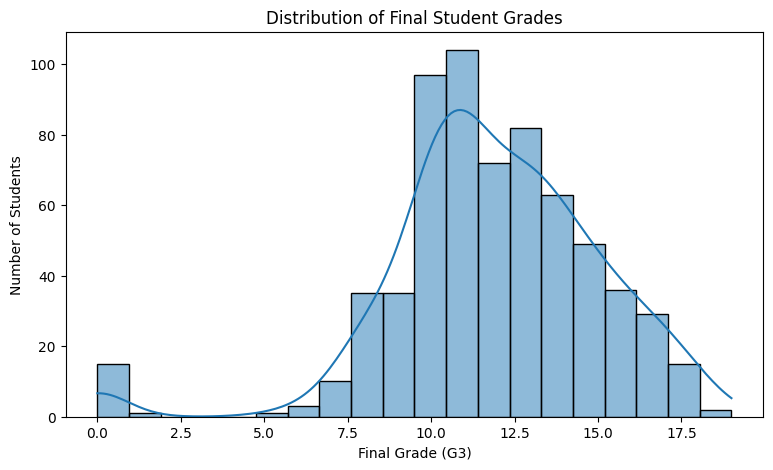

In [19]:
# Final Grade Distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    kde=True
)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

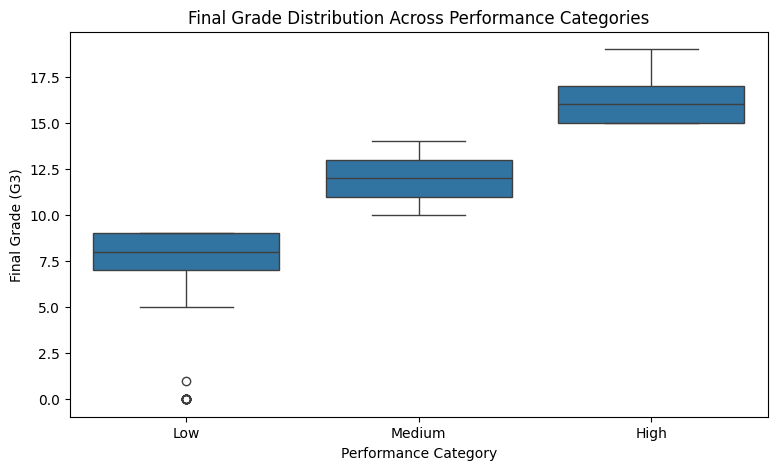

In [20]:
# Final Grade by Performance Category

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="performance_category",
    y="G3",
    order=["Low", "Medium", "High"]
)

plt.title("Final Grade Distribution Across Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Final Grade (G3)")
plt.show()

In [21]:
# Study time distribution

print(df["studytime"].value_counts().sort_index())

studytime
1    212
2    305
3     97
4     35
Name: count, dtype: int64


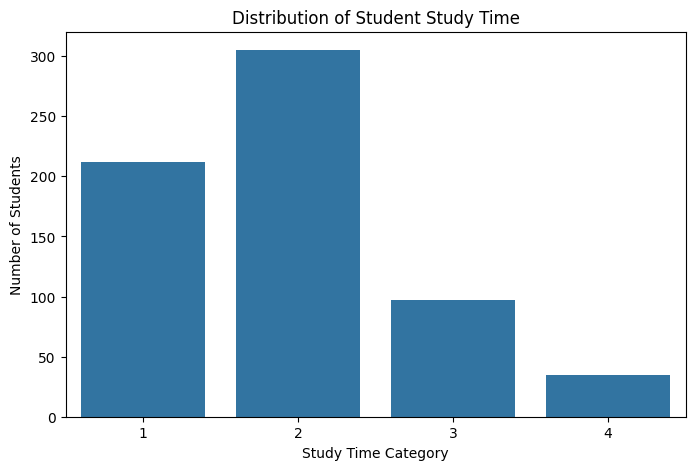

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="studytime"
)

plt.title("Distribution of Student Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

In [23]:
# Previous failures distribution

print(df["failures"].value_counts().sort_index())

failures
0    549
1     70
2     16
3     14
Name: count, dtype: int64


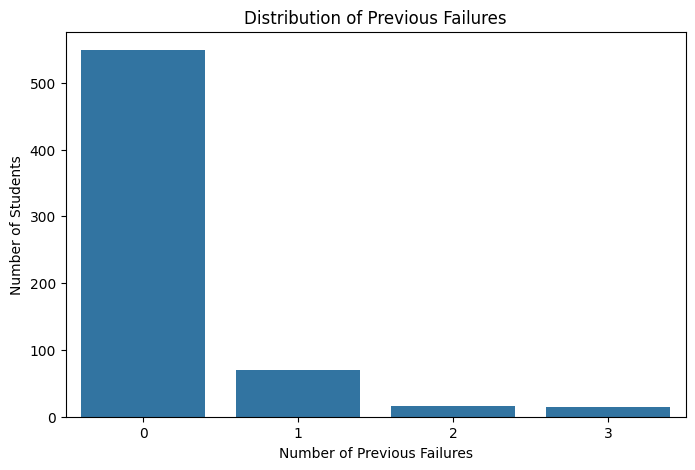

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="failures"
)

plt.title("Distribution of Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

In [25]:
# Analyze student absences

print("Minimum absences:", df["absences"].min())
print("Maximum absences:", df["absences"].max())
print("Average absences:", round(df["absences"].mean(), 2))
print("Median absences:", df["absences"].median())

Minimum absences: 0
Maximum absences: 32
Average absences: 3.66
Median absences: 2.0


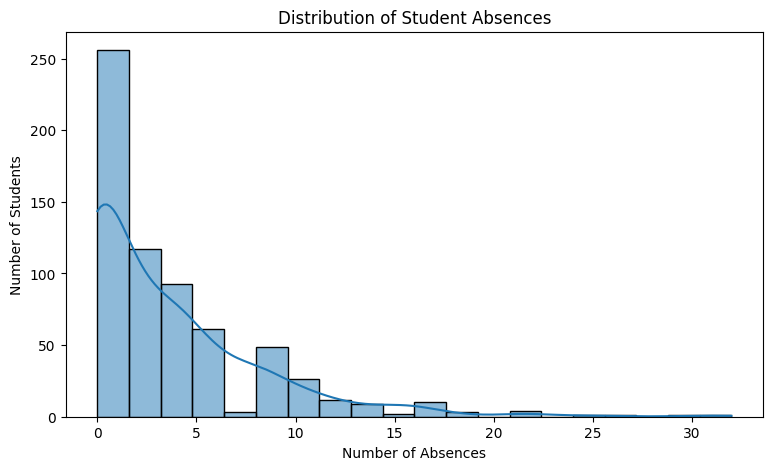

In [26]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="absences",
    bins=20,
    kde=True
)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()